<a href="https://colab.research.google.com/github/rcardocg/F1-regression/blob/main/Regresi%C3%B3n_resultado_de_la_carrera_IO2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
rohanrao_formula_1_world_championship_1950_2020_path = kagglehub.dataset_download('rohanrao/formula-1-world-championship-1950-2020')

print('Data source import complete.')


# ¿Qué afecta el resultado de la carrera?

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/formula-1-world-championship-1950-2020/races.csv
/kaggle/input/formula-1-world-championship-1950-2020/constructor_results.csv
/kaggle/input/formula-1-world-championship-1950-2020/drivers.csv
/kaggle/input/formula-1-world-championship-1950-2020/constructors.csv
/kaggle/input/formula-1-world-championship-1950-2020/lap_times.csv
/kaggle/input/formula-1-world-championship-1950-2020/status.csv
/kaggle/input/formula-1-world-championship-1950-2020/driver_standings.csv
/kaggle/input/formula-1-world-championship-1950-2020/seasons.csv
/kaggle/input/formula-1-world-championship-1950-2020/pit_stops.csv
/kaggle/input/formula-1-world-championship-1950-2020/sprint_results.csv
/kaggle/input/formula-1-world-championship-1950-2020/constructor_standings.csv
/kaggle/input/formula-1-world-championship-1950-2020/results.csv
/kaggle/input/formula-1-world-championship-1950-2020/circuits.csv
/kaggle/input/formula-1-world-championship-1950-2020/qualifying.csv


In [ ]:
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, precision_score
from sklearn.model_selection import train_test_split
import numpy as np
print("ya")

ya


# 1. Importar dataset

In [ ]:
races = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/races.csv')
circuits = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/circuits.csv')
drivers = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/drivers.csv')
results = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/results.csv')
constructors = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/constructors.csv')
pit_stops = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/pit_stops.csv')

print("races:" , races.shape)
print("circuits:", circuits.shape)
print("drivers: ", drivers.shape)
print("results: ", results.shape)
print("constructors: ", constructors.shape)
print("pit stops: ", pit_stops.shape)

races: (1125, 18)
circuits: (77, 9)
drivers:  (861, 9)
results:  (26759, 18)
constructors:  (212, 5)
pit stops:  (11371, 7)


## 1.1 Explorando el dataset

### Races

In [ ]:
races.head(10)

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
5,6,2009,6,6,Monaco Grand Prix,2009-05-24,12:00:00,http://en.wikipedia.org/wiki/2009_Monaco_Grand...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
6,7,2009,7,5,Turkish Grand Prix,2009-06-07,12:00:00,http://en.wikipedia.org/wiki/2009_Turkish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
7,8,2009,8,9,British Grand Prix,2009-06-21,12:00:00,http://en.wikipedia.org/wiki/2009_British_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
8,9,2009,9,20,German Grand Prix,2009-07-12,12:00:00,http://en.wikipedia.org/wiki/2009_German_Grand...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
9,10,2009,10,11,Hungarian Grand Prix,2009-07-26,12:00:00,http://en.wikipedia.org/wiki/2009_Hungarian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


### Circuits

In [ ]:
circuits.head(10)

,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
3,4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
4,5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park
5,6,monaco,Circuit de Monaco,Monte-Carlo,Monaco,43.73470,7.42056,7,http://en.wikipedia.org/wiki/Circuit_de_Monaco
6,7,villeneuve,Circuit Gilles Villeneuve,Montreal,Canada,45.50000,-73.52280,13,http://en.wikipedia.org/wiki/Circuit_Gilles_Vi...
7,8,magny_cours,Circuit de Nevers Magny-Cours,Magny Cours,France,46.86420,3.16361,228,http://en.wikipedia.org/wiki/Circuit_de_Nevers...
8,9,silverstone,Silverstone Circuit,Silverstone,UK,52.07860,-1.01694,153,http://en.wikipedia.org/wiki/Silverstone_Circuit
9,10,hockenheimring,Hockenheimring,Hockenheim,Germany,49.32780,8.56583,103,http://en.wikipedia.org/wiki/Hockenheimring


### Drivers

In [ ]:
drivers.head(10)

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen
5,6,nakajima,\N,NAK,Kazuki,Nakajima,1985-01-11,Japanese,http://en.wikipedia.org/wiki/Kazuki_Nakajima
6,7,bourdais,\N,BOU,Sébastien,Bourdais,1979-02-28,French,http://en.wikipedia.org/wiki/S%C3%A9bastien_Bo...
7,8,raikkonen,7,RAI,Kimi,Räikkönen,1979-10-17,Finnish,http://en.wikipedia.org/wiki/Kimi_R%C3%A4ikk%C...
8,9,kubica,88,KUB,Robert,Kubica,1984-12-07,Polish,http://en.wikipedia.org/wiki/Robert_Kubica
9,10,glock,\N,GLO,Timo,Glock,1982-03-18,German,http://en.wikipedia.org/wiki/Timo_Glock


### Results

In [ ]:
results.head(10)

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1
5,6,18,6,3,8,13,6,6,6,3.0,57,\N,\N,50,14,1:29.639,212.974,11
6,7,18,7,5,14,17,7,7,7,2.0,55,\N,\N,54,8,1:29.534,213.224,5
7,8,18,8,6,1,15,8,8,8,1.0,53,\N,\N,20,4,1:27.903,217.180,5
8,9,18,9,2,4,2,\N,R,9,0.0,47,\N,\N,15,9,1:28.753,215.100,4
9,10,18,10,7,12,18,\N,R,10,0.0,43,\N,\N,23,13,1:29.558,213.166,3


### Constructors

In [ ]:
constructors.head(10)

,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso
5,6,ferrari,Ferrari,Italian,http://en.wikipedia.org/wiki/Scuderia_Ferrari
6,7,toyota,Toyota,Japanese,http://en.wikipedia.org/wiki/Toyota_Racing
7,8,super_aguri,Super Aguri,Japanese,http://en.wikipedia.org/wiki/Super_Aguri_F1
8,9,red_bull,Red Bull,Austrian,http://en.wikipedia.org/wiki/Red_Bull_Racing
9,10,force_india,Force India,Indian,http://en.wikipedia.org/wiki/Racing_Point_Forc...


### Pit stop

In [ ]:
pit_stops.head(10)

,raceId,driverId,stop,lap,time,duration,milliseconds
0,841,153,1,1,17:05:23,26.898,26898
1,841,30,1,1,17:05:52,25.021,25021
2,841,17,1,11,17:20:48,23.426,23426
3,841,4,1,12,17:22:34,23.251,23251
4,841,13,1,13,17:24:10,23.842,23842
5,841,22,1,13,17:24:29,23.643,23643
6,841,20,1,14,17:25:17,22.603,22603
7,841,814,1,14,17:26:03,24.863,24863
8,841,816,1,14,17:26:50,25.259,25259
9,841,67,1,15,17:27:34,25.342,25342


# 2. Limpiar pit_stops

# 3. Resumen de pit_stops

In [ ]:
pit_stops['duration'] = (
    pit_stops['duration']
    .astype(str)
    .str.extract(r'(\d+\.\d+)')[0]
    .astype(float)
)

# Eliminar na
pit_stops = pit_stops.dropna(subset=['duration'])
pit_summary = (
    pit_stops
    .groupby(['raceId', 'driverId'])
    .agg(total_pit_time=('duration', 'sum'),
         count_pit_stops=('stop', 'count'))
    .reset_index()
)
pit_summary.head()

,raceId,driverId,total_pit_time,count_pit_stops
0,841,1,46.426,2
1,841,2,48.092,2
2,841,3,23.716,1
3,841,4,72.165,3
4,841,5,24.865,1


# 4. Filtrar resultados para carreras con pit_stops

In [ ]:
race_ids_with_pits = pit_summary['raceId'].unique()
results_filtered = results[results['raceId'].isin(race_ids_with_pits)]
results_filtered.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
20776,20779,841,20,9,1,1,1,1,1,25.0,58,1:29:30.259,5370259,44,4,1:29.844,212.488,1
20777,20780,841,1,1,3,2,2,2,2,18.0,58,+22.297,5392556,41,8,1:30.314,211.382,1
20778,20781,841,808,4,10,6,3,3,3,15.0,58,+30.560,5400819,55,7,1:30.064,211.969,1
20779,20782,841,4,6,5,5,4,4,4,12.0,58,+31.772,5402031,49,2,1:29.487,213.336,1
20780,20783,841,17,9,2,3,5,5,5,10.0,58,+38.171,5408430,50,3,1:29.600,213.066,1


# 5. Merge de todo

## Feature engineering

### Data imputation

In [ ]:
merged = results_filtered.merge(
    races[['raceId', 'year', 'round', 'circuitId', 'name']],
    on='raceId', how='left'
)

merged = merged.merge(
    drivers[['driverId', 'driverRef', 'nationality']],
    on='driverId', how='left'
)

merged = merged.merge(
    constructors[['constructorId', 'name']],
    on='constructorId', how='left', suffixes=('', '_constructor')
)

merged = merged.merge(
    circuits[['circuitId', 'location', 'country']],
    on='circuitId', how='left'
)

# Merge con resumen de pits
merged = merged.merge(
    pit_summary,
    on=['raceId', 'driverId'],
    how='left'
)
merged['total_pit_time'] = merged['total_pit_time'].fillna(0)
merged['count_pit_stops'] = merged['count_pit_stops'].fillna(0)

merged.head(10)

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,round,circuitId,name,driverRef,nationality,name_constructor,location,country,total_pit_time,count_pit_stops
0,20779,841,20,9,1,1,1,1,1,25.0,...,1,1,Australian Grand Prix,vettel,German,Red Bull,Melbourne,Australia,46.639,2.0
1,20780,841,1,1,3,2,2,2,2,18.0,...,1,1,Australian Grand Prix,hamilton,British,McLaren,Melbourne,Australia,46.426,2.0
2,20781,841,808,4,10,6,3,3,3,15.0,...,1,1,Australian Grand Prix,petrov,Russian,Renault,Melbourne,Australia,50.218,2.0
3,20782,841,4,6,5,5,4,4,4,12.0,...,1,1,Australian Grand Prix,alonso,Spanish,Ferrari,Melbourne,Australia,72.165,3.0
4,20783,841,17,9,2,3,5,5,5,10.0,...,1,1,Australian Grand Prix,webber,Australian,Red Bull,Melbourne,Australia,72.176,3.0
5,20784,841,18,1,4,4,6,6,6,8.0,...,1,1,Australian Grand Prix,button,British,McLaren,Melbourne,Australia,62.851,3.0
6,20785,841,13,6,6,8,7,7,7,6.0,...,1,1,Australian Grand Prix,massa,Brazilian,Ferrari,Melbourne,Australia,72.437,3.0
7,20786,841,67,5,18,10,8,8,8,4.0,...,1,1,Australian Grand Prix,buemi,Swiss,Toro Rosso,Melbourne,Australia,48.442,2.0
8,20787,841,16,10,14,16,9,9,9,2.0,...,1,1,Australian Grand Prix,sutil,German,Force India,Melbourne,Australia,49.849,2.0
9,20788,841,814,10,15,14,10,10,10,1.0,...,1,1,Australian Grand Prix,resta,British,Force India,Melbourne,Australia,49.195,2.0


### 1. Transformaciones numéricas y de pits

In [ ]:
assert 'merged' in globals(), "El DataFrame `merged` debe existir antes de esta celda."
created_feats = []

def has(cols):
    return all(col in merged.columns for col in cols)

# --- Pits: intensidad y calidad del pit ---
if has(['total_pit_time','count_pit_stops']):
    merged['avg_pit_time'] = np.where(merged['count_pit_stops']>0,
                                      merged['total_pit_time'] / merged['count_pit_stops'],
                                      0.0)
    merged['has_pit_stop'] = (merged['count_pit_stops'] > 0).astype(int)
    merged['pit_time_log1p'] = np.log1p(merged['total_pit_time'].clip(lower=0))
    created_feats += ['avg_pit_time','has_pit_stop','pit_time_log1p']

    if 'grid' in merged.columns:
        merged['grid_x_pits'] = merged['grid'] * merged['count_pit_stops']
        merged['grid_x_total_pit_time'] = merged['grid'] * merged['total_pit_time'].fillna(0)
        created_feats += ['grid_x_pits','grid_x_total_pit_time']

### 2. Normalización por carrera

In [ ]:
if has(['raceId','total_pit_time']):
    merged['total_pit_time_z_race'] = merged.groupby('raceId')['total_pit_time']\
                                            .transform(lambda s: (s - s.mean())/s.std(ddof=0) if s.std(ddof=0)>0 else 0)
    created_feats += ['total_pit_time_z_race']

if has(['raceId','count_pit_stops']):
    merged['count_pit_stops_z_race'] = merged.groupby('raceId')['count_pit_stops']\
                                             .transform(lambda s: (s - s.mean())/s.std(ddof=0) if s.std(ddof=0)>0 else 0)
    created_feats += ['count_pit_stops_z_race']

### 3. Grid y posición relativa

In [ ]:
if 'grid' in merged.columns:
    merged['grid_is_missing'] = merged['grid'].isna().astype(int)
    created_feats += ['grid_is_missing']

    if 'raceId' in merged.columns:
        merged['drivers_per_race'] = merged.groupby('raceId')['grid'].transform('size')
        merged['grid_from_back'] = np.where(merged['grid'].notna(),
                                            merged['drivers_per_race'] - merged['grid'] + 1,
                                            np.nan)
        merged['grid_rel01'] = np.where(
            (merged['grid'].notna()) & (merged['drivers_per_race']>1),
            (merged['grid'] - 1) / (merged['drivers_per_race'] - 1),
            np.nan
        )
        created_feats += ['drivers_per_race','grid_from_back','grid_rel01']

        def _grid_bin(g):
            q1 = g.quantile(1/3)
            q2 = g.quantile(2/3)
            return pd.cut(g, bins=[-np.inf, q1, q2, np.inf], labels=['front','mid','back'])
        merged['grid_bin'] = merged.groupby('raceId', group_keys=False)['grid'].apply(
            lambda s: _grid_bin(s) if s.notna().sum()>=3 else pd.Series(['mid']*len(s), index=s.index)
        )
    else:
        q1 = merged['grid'].quantile(1/3)
        q2 = merged['grid'].quantile(2/3)
        merged['grid_bin'] = pd.cut(merged['grid'], bins=[-np.inf, q1, q2, np.inf], labels=['front','mid','back'])
        created_feats += ['grid_bin']

    merged['front_row'] = (merged['grid']<=2).astype(int)
    merged['top5_grid'] = (merged['grid']<=5).astype(int)
    created_feats += ['front_row','top5_grid']


### 4. Encodings de frecuencia

In [ ]:
if 'driverId' in merged.columns:
    merged['driver_freq'] = merged['driverId'].map(merged['driverId'].value_counts()).astype(float)
    created_feats += ['driver_freq']

if 'constructorId' in merged.columns:
    merged['constructor_freq'] = merged['constructorId'].map(merged['constructorId'].value_counts()).astype(float)
    created_feats += ['constructor_freq']


### 5. Variables relativas por equipo y vueltas

In [ ]:
if has(['raceId','constructorId']) and 'grid' in merged.columns:
    team_grid_mean = merged.groupby(['raceId','constructorId'])['grid'].transform('mean')
    merged['team_grid_rel'] = merged['grid'] - team_grid_mean
    created_feats += ['team_grid_rel']

if has(['laps']) and 'count_pit_stops' in merged.columns:
    merged['pit_stops_per_10laps'] = np.where(merged['laps']>0,
                                              10.0*merged['count_pit_stops']/merged['laps'], np.nan)
    created_feats += ['pit_stops_per_10laps']

if has(['laps','total_pit_time']):
    merged['pit_time_per_lap'] = np.where(merged['laps']>0,
                                          merged['total_pit_time']/merged['laps'], np.nan)
    created_feats += ['pit_time_per_lap']


### 6. Agregados contextuales por circuito

In [ ]:
if has(['circuitId','total_pit_time']):
    circuit_pit_mean = merged.groupby('circuitId')['total_pit_time'].transform('mean')
    merged['circuit_pit_mean'] = circuit_pit_mean
    created_feats += ['circuit_pit_mean']

### 7. Limpieza y reporte final

In [ ]:
num_cols = merged.select_dtypes(include=[np.number]).columns
for c in num_cols:
    infmask = ~np.isfinite(merged[c])
    if infmask.any():
        merged.loc[infmask, c] = np.nan

print(f"[Feature Engineering] Columnas creadas: {created_feats}")
print(f"[Feature Engineering] merged shape: {merged.shape}")


[Feature Engineering] Columnas creadas: ['avg_pit_time', 'has_pit_stop', 'pit_time_log1p', 'grid_x_pits', 'grid_x_total_pit_time', 'total_pit_time_z_race', 'count_pit_stops_z_race', 'grid_is_missing', 'drivers_per_race', 'grid_from_back', 'grid_rel01', 'front_row', 'top5_grid', 'driver_freq', 'constructor_freq', 'team_grid_rel', 'pit_stops_per_10laps', 'pit_time_per_lap', 'circuit_pit_mean']
[Feature Engineering] merged shape: (5960, 49)


# 6. Seleccionar variables

## 6.1 Variables dependientes e independientes

In [ ]:
y = merged[['positionOrder']]
y.head(10)

,positionOrder
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


## 6.2 P-Values

In [ ]:
x_n = [
    'grid',
    'total_pit_time',
    'count_pit_stops',
    'year',
    'round',
    'circuitId',
    'constructorId',
    'driverId'
]

x = merged[x_n]
x = pd.get_dummies(x, columns=['circuitId','constructorId','driverId'],drop_first=True)
x = x.astype(float)
x = sm.add_constant(x)
model = sm.OLS(y,x)
results_sm = model.fit()
p_values = results_sm.pvalues.sort_values()
print(p_values)

grid                 3.227084e-90
count_pit_stops      3.398403e-47
driverId_30          2.500143e-24
constructorId_131    2.620995e-24
total_pit_time       4.912064e-21
                         ...     
driverId_817         8.721157e-01
driverId_155         9.048683e-01
constructorId_214    9.603262e-01
constructorId_210    9.859944e-01
driverId_829         9.903946e-01
Length: 138, dtype: float64


In [ ]:
main_vars = ['grid', 'total_pit_time']
signif_dummies = p_values[(p_values.index.str.startswith('driverId_') |
                           p_values.index.str.startswith('constructorId_')) &
                          (p_values < 0.05)]
print("Variables principales:")
print(p_values[main_vars])
print("\nPilotos y constructores significativos (p < 0.05):")
print(signif_dummies)

Variables principales:
grid              3.227084e-90
total_pit_time    4.912064e-21
dtype: float64

Pilotos y constructores significativos (p < 0.05):
driverId_30          2.500143e-24
constructorId_131    2.620995e-24
constructorId_9      6.982185e-12
driverId_813         1.025023e-09
constructorId_6      1.982970e-09
driverId_3           2.385410e-07
driverId_847         1.168269e-06
driverId_849         6.783393e-06
driverId_858         1.920897e-05
driverId_9           2.215714e-05
driverId_846         6.103292e-05
constructorId_164    1.723847e-04
driverId_853         4.092217e-04
constructorId_208    8.293739e-04
constructorId_207    1.370796e-03
driverId_16          1.837477e-03
driverId_857         2.150817e-03
driverId_22          2.217014e-03
driverId_154         2.364831e-03
driverId_854         2.821313e-03
constructorId_209    2.822849e-03
constructorId_211    5.405588e-03
constructorId_10     5.638513e-03
driverId_845         8.380261e-03
driverId_835         8.509726e-0

In [ ]:
signif_drivers = [30, 813, 3, 847, 849, 858, 9, 846, 853, 16, 857, 22, 154, 854, 825, 856, 821, 811, 814, 830]

recent_years = merged[merged['year'] >= 2024]

unique_recent_drivers = recent_years[recent_years['driverId'].isin(signif_drivers)][['driverId', 'driverRef', 'nationality']].drop_duplicates()

unique_recent_drivers

,driverId,driverRef,nationality
5481,830,max_verstappen,Dutch
5485,847,russell,British
5486,846,norris,British
5488,857,piastri,Australian
5492,825,kevin_magnussen,Danish
5500,858,sargeant,American


In [ ]:
signif_constructors = [131, 9, 6, 164, 208, 207, 209, 211, 10, 15, 5, 205]


constructor_dict = constructors.set_index('constructorId')['name'].to_dict()
merged['constructor_name'] = merged['constructorId'].map(constructor_dict)

unique_recent_constructors = recent_years[recent_years['constructorId'].isin(signif_constructors)][
    ['constructorId', 'constructor_name']
].drop_duplicates()

unique_recent_constructors

,constructorId,constructor_name
5481,9,Red Bull
5483,6,Ferrari
5485,131,Mercedes
5491,15,Sauber


In [ ]:
relevant_dummies = ['driverId_830', 'driverId_847', 'driverId_846', 'driverId_857', 'driverId_825', 'driverId_858', 'constructor_9', 'constructor_6', 'constructor_131', 'constructor_15']

In [ ]:
x_main = merged[main_vars].copy()
x_main.head()

,grid,total_pit_time
0,1,46.639
1,2,46.426
2,6,50.218
3,5,72.165
4,3,72.176


# Train/Validation/Test Split

In [ ]:
main_vars = ['grid', 'total_pit_time']
random_state = 42

# 80/10/10 split
train_idx, temp_idx = train_test_split(merged.index, test_size=0.30, random_state=random_state, shuffle=True)

val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=random_state, shuffle=True)

print("N total:", len(merged))
print("Train:", len(train_idx), "Val:", len(val_idx), "Test:", len(test_idx))


N total: 5960
Train: 4172 Val: 894 Test: 894


In [ ]:
x_train= x_main.loc[train_idx].copy()
x_val = x_main.loc[val_idx].copy()
x_test = x_main.loc[test_idx].copy()
y_train = y.loc[train_idx].copy()
y_val   = y.loc[val_idx].copy()
y_test  = y.loc[test_idx].copy()

# Añadir constante para statsmodels
x_train = sm.add_constant(x_train)
x_val = sm.add_constant(x_val)
x_test = sm.add_constant(x_test)

# Comprobación rápida de shapes
print("x - train/val/test:", x_train.shape, x_val.shape, x_test.shape)
print("y - train/val/test:", y_train.shape, y_val.shape, y_test.shape)


x - train/val/test: (4172, 3) (894, 3) (894, 3)
y - train/val/test: (4172, 1) (894, 1) (894, 1)


# Modelo Simple (3 variables)

## Resultados

In [ ]:
train_simple = sm.add_constant(x_train[main_vars])
val_simple = sm.add_constant(x_val[main_vars])
test_simple = sm.add_constant(x_test[main_vars])

model_simple = sm.OLS(y_train, train_simple).fit()
print(model_simple.summary())


                            OLS Regression Results                            
Dep. Variable:          positionOrder   R-squared:                       0.361
Model:                            OLS   Adj. R-squared:                  0.361
Method:                 Least Squares   F-statistic:                     1179.
Date:                Mon, 10 Nov 2025   Prob (F-statistic):               0.00
Time:                        03:25:19   Log-Likelihood:                -12542.
No. Observations:                4172   AIC:                         2.509e+04
Df Residuals:                    4169   BIC:                         2.511e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              5.8793      0.194     30.

In [ ]:
y_pred_train = model_simple.predict(train_simple)
y_pred_val   = model_simple.predict(val_simple)
y_pred_test  = model_simple.predict(test_simple)

def metrics(y_true, y_pred, name="set"):
    # Asegurar que y_true sea array 1D
    if isinstance(y_true, (pd.DataFrame, pd.Series)):
        y_true = np.ravel(y_true.values)
    else:
        y_true = np.ravel(y_true)

    # Detectar si el modelo es clasificación o regresión
    unique_vals = np.unique(y_true)
    is_classification = np.array_equal(unique_vals, [0,1]) or (
        np.issubdtype(unique_vals.dtype, np.integer) and len(unique_vals) < 15
    )

    if is_classification:
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
        print(f"\n{name.upper()} Metrics (Clasificación):")
        print(f"Accuracy : {acc:.3f}")
        print(f"Precisión: {prec:.3f}")
        return acc, prec

    else:
        mae = mean_absolute_error(y_true, y_pred)
        rmse = mean_squared_error(y_true, y_pred, squared=False)
        r2 = r2_score(y_true, y_pred)

        # Accuracy "relativa" (qué tan cerca está la predicción promedio)
        acc = 1 - (mae / (np.max(y_true) - np.min(y_true) + 1e-9))
        # Precisión como correlación entre valores reales y predichos
        prec = np.corrcoef(y_true, y_pred)[0,1]

        print(f"\n{name.upper()} Metrics (Regresión):")
        print(f"MAE       : {mae:.3f}")
        print(f"RMSE      : {rmse:.3f}")
        print(f"R²        : {r2:.3f}")
        print(f"Accuracy  : {acc:.3f}")
        print(f"Precisión : {prec:.3f}")

        return mae, rmse, r2, acc, prec

# Ejecutar para cada conjunto
metrics(y_train, y_pred_train, "train")
metrics(y_val, y_pred_val, "val")
metrics(y_test, y_pred_test, "test")


TRAIN Metrics (Regresión):
MAE       : 3.856
RMSE      : 4.890
R²        : 0.361
Accuracy  : 0.832
Precisión : 0.601

VAL Metrics (Regresión):
MAE       : 3.950
RMSE      : 5.002
R²        : 0.331
Accuracy  : 0.828
Precisión : 0.576

TEST Metrics (Regresión):
MAE       : 3.921
RMSE      : 4.943
R²        : 0.356
Accuracy  : 0.830
Precisión : 0.597


(3.9205713125590753,
 4.942969097651814,
 0.3560563204013152,
 0.8295403777222341,
 0.5969045522199496)

# Modelo complejo (13 variables)

In [ ]:
merged_dummies = pd.get_dummies(
    merged,
    columns=['circuitId', 'constructorId', 'driverId'],
    drop_first=True,  # evita colinealidad perfecta
    dtype=float
)

merged_dummies.head


<bound method NDFrame.head of       resultId  raceId number  grid position positionText  positionOrder  \
0        20779     841      1     1        1            1              1   
1        20780     841      3     2        2            2              2   
2        20781     841     10     6        3            3              3   
3        20782     841      5     5        4            4              4   
4        20783     841      2     3        5            5              5   
...        ...     ...    ...   ...      ...          ...            ...   
5955     26760    1144     20    14       16           16             16   
5956     26761    1144     30    12       17           17             17   
5957     26762    1144     77     9       \N            R             18   
5958     26763    1144     43    20       \N            R             19   
5959     26764    1144     11    10       \N            R             20   

      points  laps         time  ... driverId_853 driverI

In [ ]:
relevant_dummies_updated = [
    'driverId_830', 'driverId_847', 'driverId_846', 'driverId_857', 'driverId_825', 'driverId_858',
    'constructorId_9', 'constructorId_6', 'constructorId_131', 'constructorId_15'
]

In [ ]:
x_complex = merged_dummies[main_vars + relevant_dummies_updated].copy()
x_complex.head()

,grid,total_pit_time,driverId_830,driverId_847,driverId_846,driverId_857,driverId_825,driverId_858,constructorId_9,constructorId_6,constructorId_131,constructorId_15
0,1,46.639,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,2,46.426,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,6,50.218,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5,72.165,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,3,72.176,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
# Split 70/15/15 usando los índices que ya definiste
x_train = sm.add_constant(x_complex.loc[train_idx])
x_val   = sm.add_constant(x_complex.loc[val_idx])
x_test  = sm.add_constant(x_complex.loc[test_idx])


In [ ]:
model_complex = sm.OLS(y_train, x_train).fit()
print(model_complex.summary())

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2


                            OLS Regression Results                            
Dep. Variable:          positionOrder   R-squared:                       0.415
Model:                            OLS   Adj. R-squared:                  0.414
Method:                 Least Squares   F-statistic:                     246.2
Date:                Mon, 10 Nov 2025   Prob (F-statistic):               0.00
Time:                        03:25:26   Log-Likelihood:                -12357.
No. Observations:                4172   AIC:                         2.474e+04
Df Residuals:                    4159   BIC:                         2.482e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 8.6476      0.24

In [ ]:
y_pred_train_c = model_complex.predict(x_train)
y_pred_val_c   = model_complex.predict(x_val)
y_pred_test_c  = model_complex.predict(x_test)

def metrics(y_true, y_pred, name="set"):
    # Asegurar formato vectorial 1D
    if isinstance(y_true, (pd.DataFrame, pd.Series)):
        y_true = np.ravel(y_true.values)
    else:
        y_true = np.ravel(y_true)

    # Métricas principales
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2 = r2_score(y_true, y_pred)

    # Métricas adicionales
    acc = 1 - (mae / (np.max(y_true) - np.min(y_true) + 1e-9))  # Accuracy relativa
    prec = np.corrcoef(y_true, y_pred)[0, 1]                    # Precisión (correlación)

    print(f"\n{name.upper()} Metrics (Regresión):")
    print(f"MAE       : {mae:.3f}")
    print(f"RMSE      : {rmse:.3f}")
    print(f"R²        : {r2:.3f}")
    print(f"Accuracy  : {acc:.3f}")
    print(f"Precisión : {prec:.3f}")

    return mae, rmse, r2, acc, prec

metrics(y_train, y_pred_train_c, "train")
metrics(y_val, y_pred_val_c, "val")
metrics(y_test, y_pred_test_c, "test")


TRAIN Metrics (Regresión):
MAE       : 3.656
RMSE      : 4.679
R²        : 0.415
Accuracy  : 0.841
Precisión : 0.644

VAL Metrics (Regresión):
MAE       : 3.822
RMSE      : 4.860
R²        : 0.368
Accuracy  : 0.834
Precisión : 0.608

TEST Metrics (Regresión):
MAE       : 3.740
RMSE      : 4.766
R²        : 0.401
Accuracy  : 0.837
Precisión : 0.634


(3.7398869278699483,
 4.76587838252553,
 0.401370650554859,
 0.8373962205344633,
 0.6339378532692054)

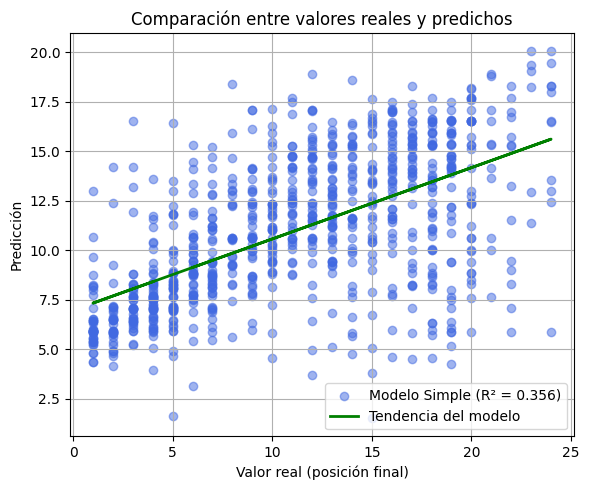

In [ ]:
import matplotlib.pyplot as plt
y_true = np.ravel(y_test)
y_pred = np.ravel(y_pred_test)

# Calcular R²
r2 = r2_score(y_true, y_pred)

m, b = np.polyfit(y_true, y_pred, 1)
# Calcular límites del gráfico
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())

# Gráfico de dispersión
plt.figure(figsize=(6,5))
plt.scatter(y_true, y_pred, alpha=0.5, color='royalblue', label=f"Modelo Simple (R² = {r2:.3f})")

# Línea
plt.plot(y_true, m * y_true + b, color="green", linewidth=2, label="Tendencia del modelo")

# Etiquetas y estilo
plt.xlabel("Valor real (posición final)")
plt.ylabel("Predicción")
plt.title("Comparación entre valores reales y predichos")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

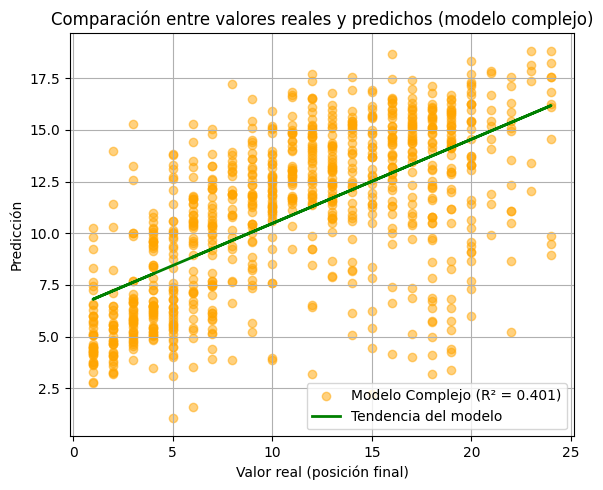

In [ ]:

# Aplanar vectores
y_true = np.ravel(y_test)
y_pred_c = np.ravel(y_pred_test_c)

# Calcular R²
r2_c = r2_score(y_true, y_pred_c)

# Calcular la línea de tendencia (ajuste lineal)
m, b = np.polyfit(y_true, y_pred_c, 1)

# Crear gráfico
plt.figure(figsize=(6,5))
plt.scatter(y_true, y_pred_c, color="orange", alpha=0.5,
            label=f"Modelo Complejo (R² = {r2_c:.3f})")

# Línea de tendencia verde
plt.plot(y_true, m * y_true + b, color="green", linewidth=2, label="Tendencia del modelo")

# Etiquetas y formato
plt.xlabel("Valor real (posición final)")
plt.ylabel("Predicción")
plt.title("Comparación entre valores reales y predichos (modelo complejo)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()